In [ ]:
# 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

결제금액 전처리

In [ ]:
import pandas as pd

# 1) CSV 파일 불러오기
file_path = '/content/인천e음카드 업종별_지역별_일별_결제금액(2020.07~2025.02).csv'
df = pd.read_csv(file_path, encoding='utf-8')

# 원본 데이터프레임 정보 확인
print("원본 데이터프레임 정보:")
print(df.info())

# 2) 숫자형으로 변환할 컬럼 리스트 지정 (결제금액 관련 컬럼)
numeric_cols = [
    "문화_취미_영화관", "숙박", "약국", "연료",
    "유통업영리_편의점", "일반휴게음식", "학원", "기타", "전체금액"
]

# 3) 각 컬럼에 대해 쉼표 등 불필요한 문자를 제거한 후 숫자형으로 변환
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

print("\n숫자형 변환 후 데이터프레임 정보:")
print(df.info())

# 4) 지역 컬럼 정제: 앞뒤 공백 제거
df["지역"] = df["지역"].astype(str).str.strip()

# 5) "일자" 컬럼을 datetime 형식으로 변환 (오류 발생 시 NaT 처리)
df["일자"] = pd.to_datetime(df["일자"], errors="coerce")

# 6) "지역" 컬럼에서 "ETC"와 "기타"에 해당하는 행 제거
df = df[~df["지역"].isin(["ETC", "기타"])].copy()

# 7) "전체금액"이 결측인 행에 대해 다른 결제 항목(전체금액 제외)을 합산하여 채우기
calc_cols = [col for col in numeric_cols if col != "전체금액"]
df["전체금액"] = df["전체금액"].fillna(df[calc_cols].sum(axis=1))

# 8) "일자" 컬럼의 NaT는 제거하고, 숫자형 결제금액 컬럼에 대해서만 NaN을 0으로 채우기
df = df.dropna(subset=["일자"])  # 일자에 NaT가 있는 행 제거
df[numeric_cols] = df[numeric_cols].fillna(0)

# 최종 전처리된 데이터프레임 정보 및 일부 데이터 확인
print("\n최종 전처리된 데이터프레임 정보:")
print(df.info())
display(df.head())

# (선택사항) 일자별 전체금액 합계 데이터프레임 생성
daily_total = df.groupby("일자")["전체금액"].sum().reset_index()
print("\n일자별 전체금액 합계 데이터프레임:")
display(daily_total)

# 전처리된 데이터프레임과 일자별 합계 데이터를 파일로 저장
df.to_csv('/content/전처리된_인천e음카드_데이터.csv', index=False, encoding='utf-8-sig')
daily_total.to_csv('/content/일자별_전체금액_합계.csv', index=False, encoding='utf-8-sig')

print("\n파일 저장이 완료되었습니다.")


원본 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18683 entries, 0 to 18682
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   일자         18683 non-null  object
 1   지역         18682 non-null  object
 2   문화_취미_영화관  18588 non-null  object
 3   숙박         18681 non-null  object
 4   약국         18683 non-null  object
 5   연료         18683 non-null  object
 6   유통업영리_편의점  18683 non-null  object
 7   일반휴게음식     18683 non-null  object
 8   학원         18654 non-null  object
 9   기타         18683 non-null  object
 10  전체금액       16670 non-null  object
dtypes: object(11)
memory usage: 1.6+ MB
None

숫자형 변환 후 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18683 entries, 0 to 18682
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   일자         18683 non-null  object 
 1   지역         18682 non-null  object 
 2   문화_취미_영화관  18490 non-null  fl

,일자,지역,문화_취미_영화관,숙박,약국,연료,유통업영리_편의점,일반휴게음식,학원,기타,전체금액
0,2020-07-01,인천광역시 서구,339850.0,920000.0,74247520.0,151586926.0,125045460.0,525987131.0,500068731.0,1.149365e+09,2.527560e+09
1,2020-07-01,인천광역시 계양구,73700.0,658000.0,32160090.0,31261772.0,39270100.0,181410283.0,99805547.0,3.652526e+08,7.498921e+08
2,2020-07-01,인천광역시 남동구,174800.0,1285400.0,64921787.0,80724324.0,89830030.0,413610566.0,258080871.0,8.642418e+08,1.772870e+09
3,2020-07-01,인천광역시 동구,8000.0,135000.0,6566380.0,8814943.0,7892090.0,29655575.0,16634500.0,7.855600e+07,1.482625e+08
4,2020-07-01,인천광역시 중구,133200.0,2352910.0,17761890.0,27862633.0,35747040.0,155868680.0,82465012.0,2.270587e+08,5.492501e+08



일자별 전체금액 합계 데이터프레임:


,일자,전체금액
0,2020-07-01,1.030404e+10
1,2020-07-02,9.845477e+09
2,2020-07-03,1.073054e+10
3,2020-07-04,1.159965e+10
4,2020-07-05,8.196899e+09
...,...,...
1699,2025-02-24,5.965051e+09
1700,2025-02-25,6.462001e+09
1701,2025-02-26,6.570959e+09
1702,2025-02-27,5.922199e+09



파일 저장이 완료되었습니다.


현재 설정된 폰트: NanumBarunGothic
결측치 개수
일자           0
지역           0
문화_취미_영화관    0
숙박           0
약국           0
연료           0
유통업영리_편의점    0
일반휴게음식       0
학원           0
기타           0
전체금액         0
dtype: int64


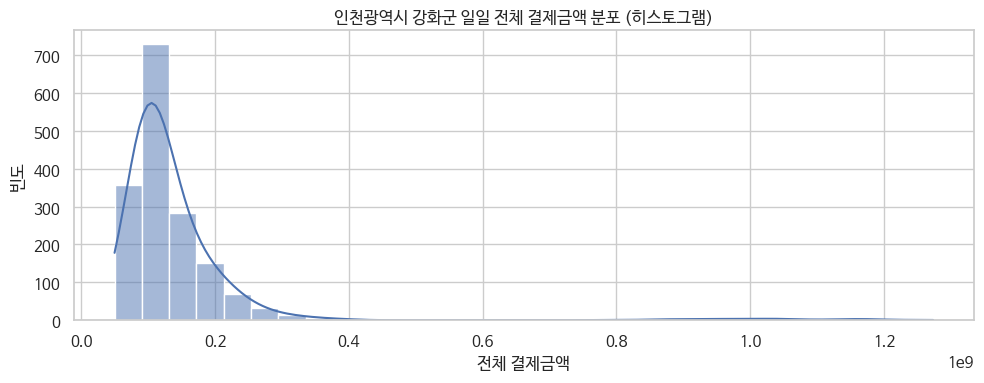

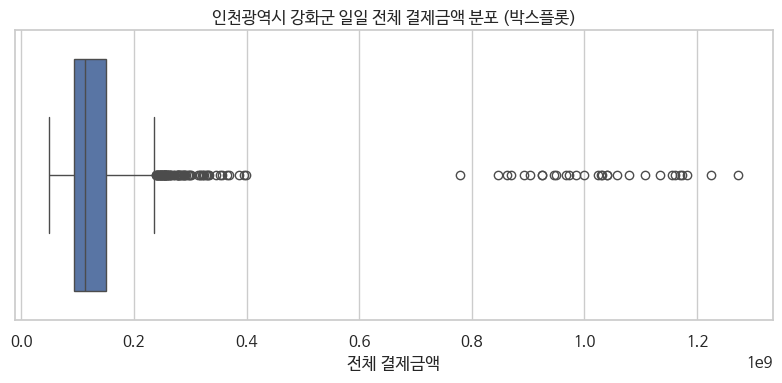

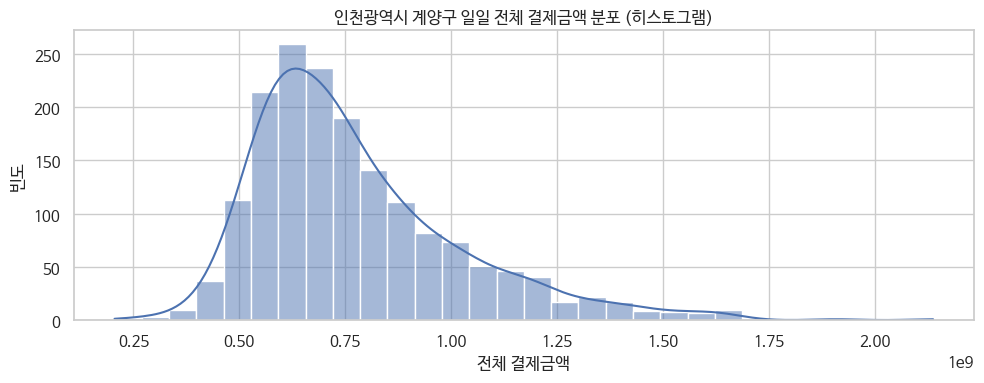

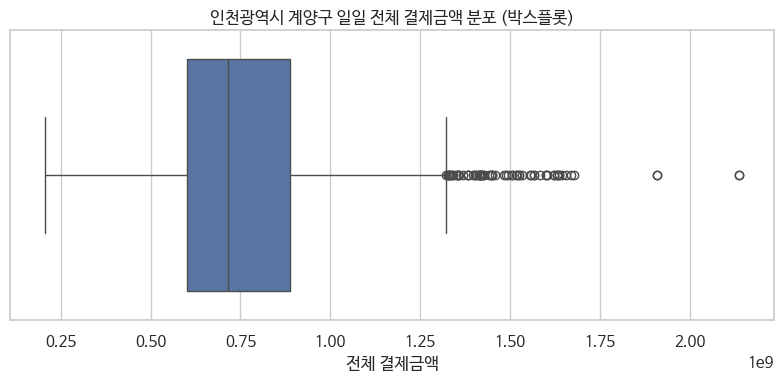

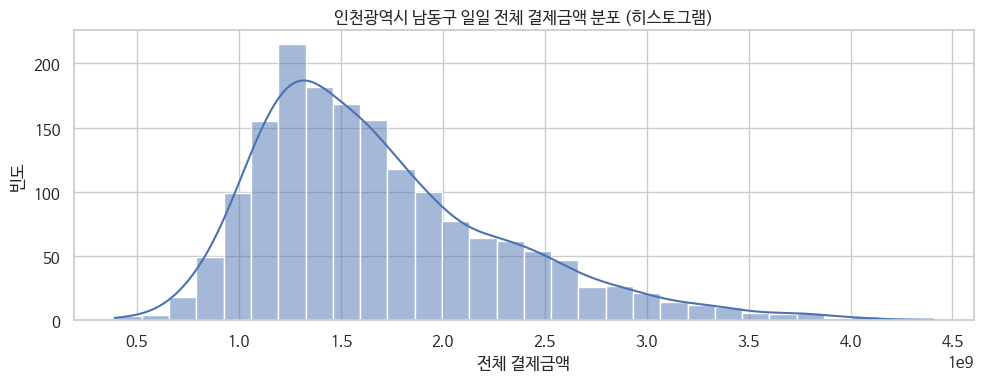

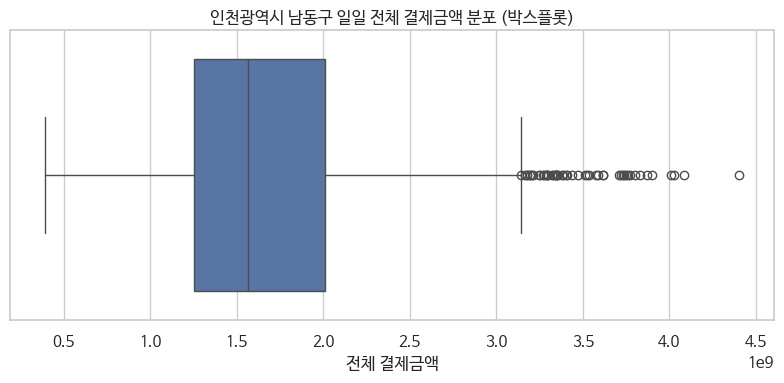

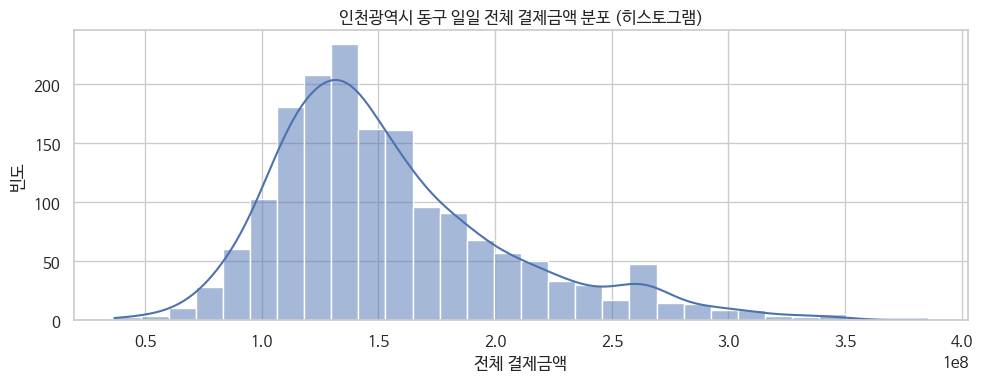

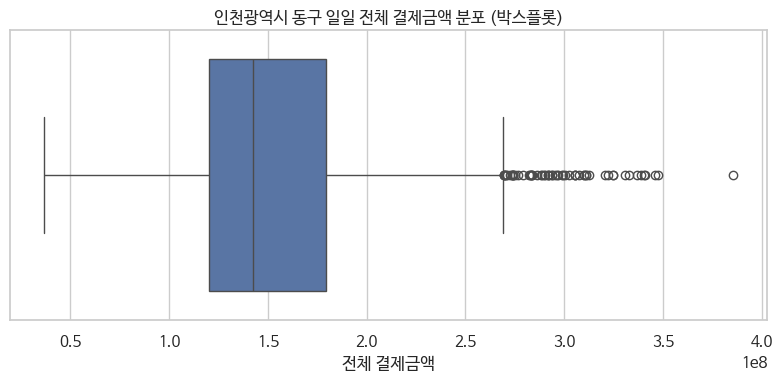

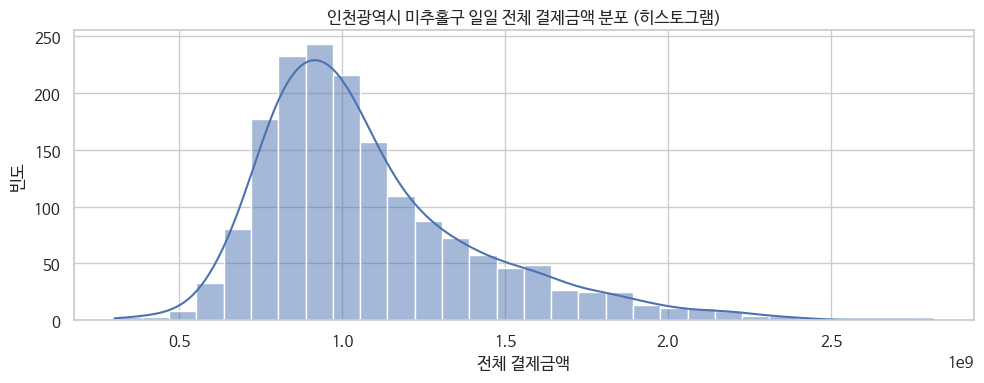

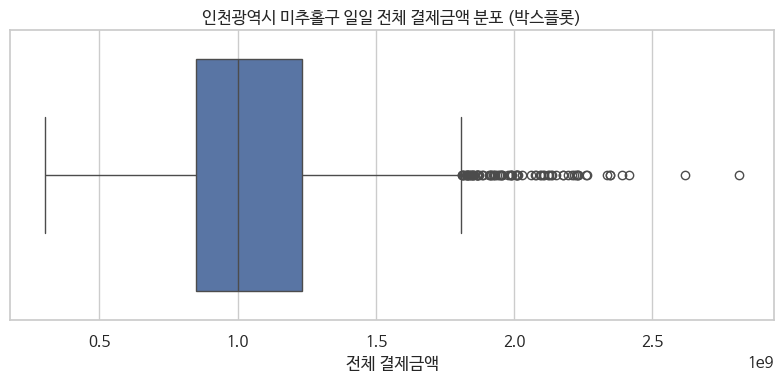

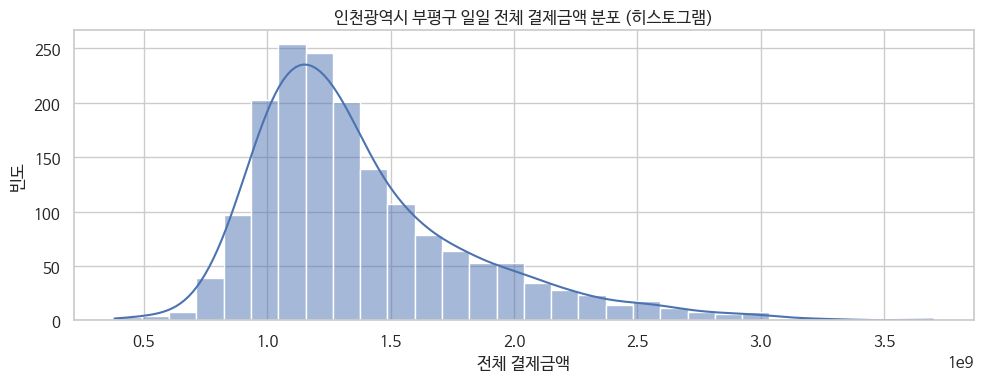

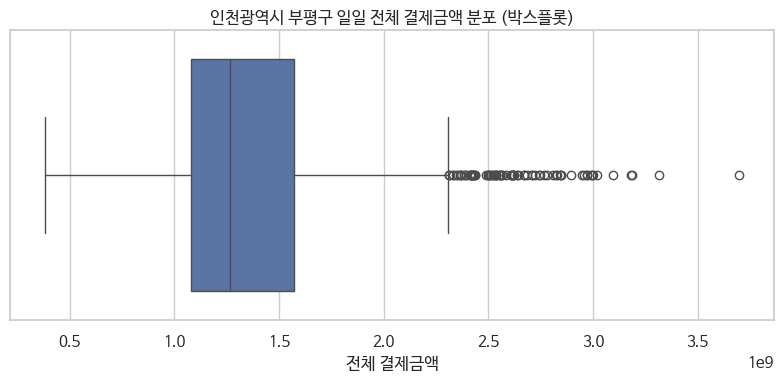

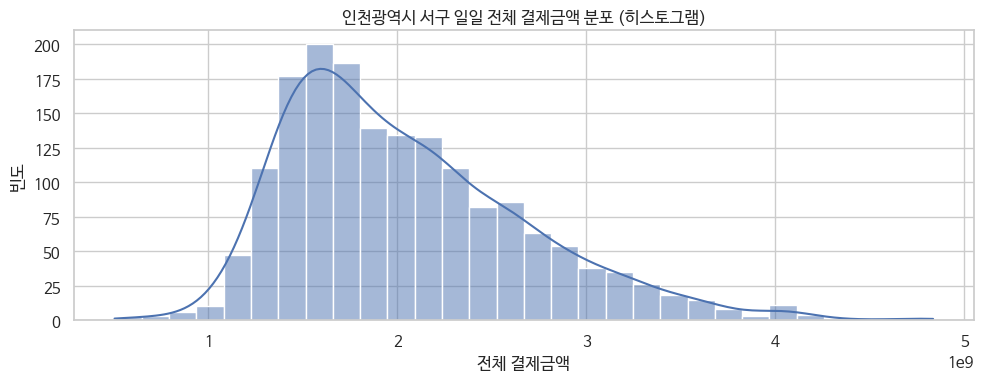

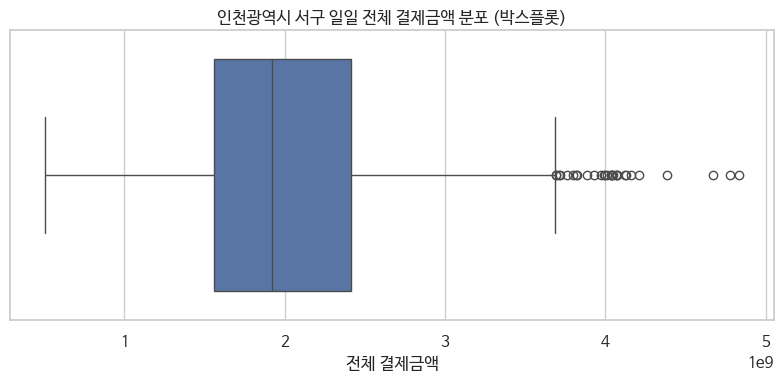

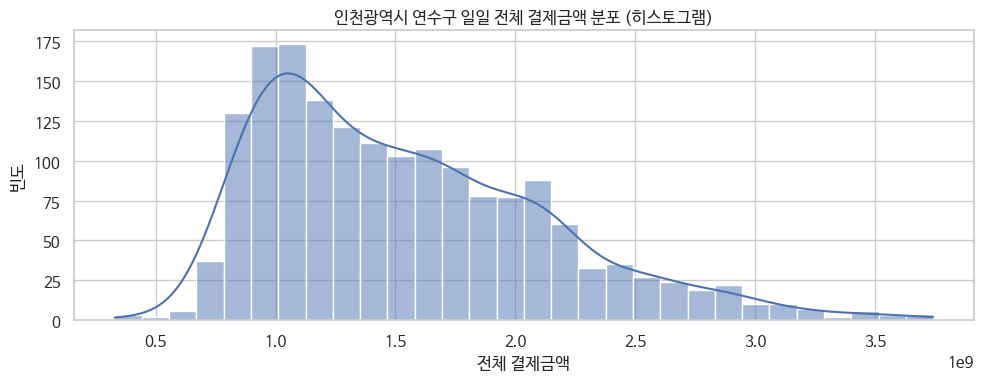

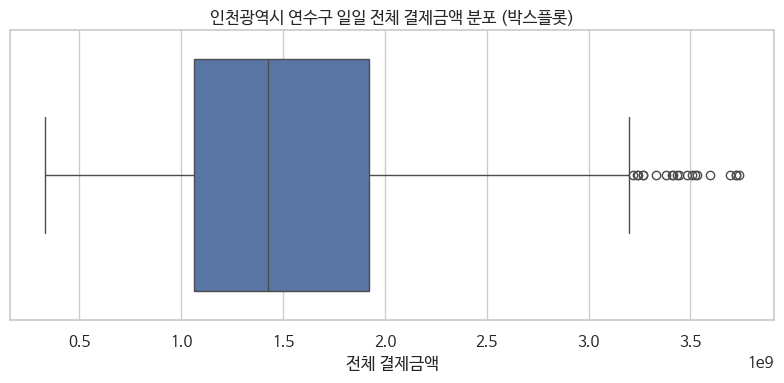

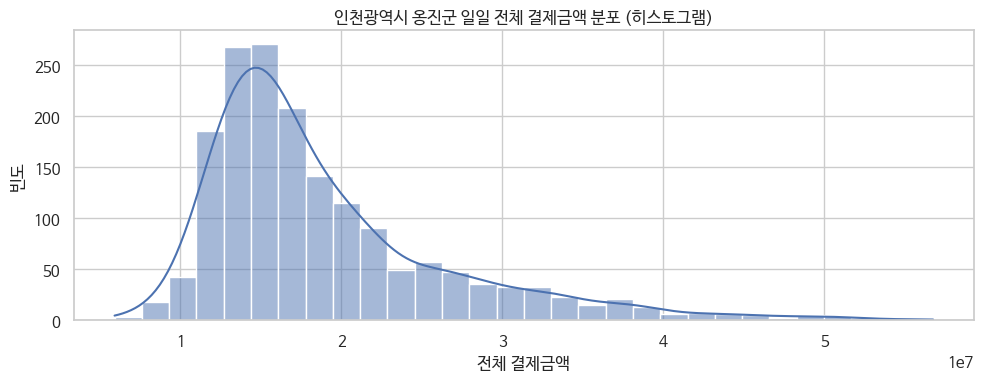

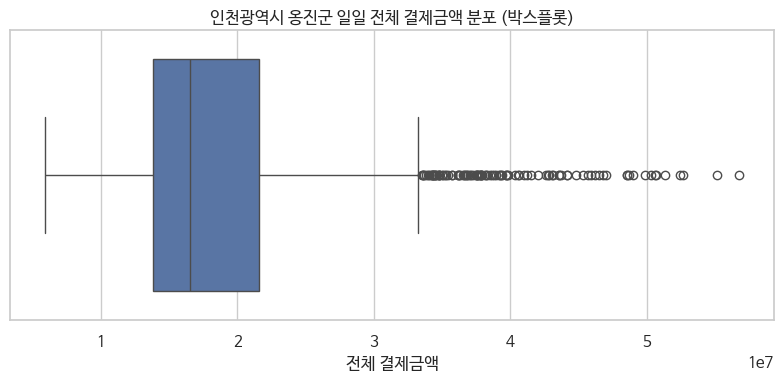

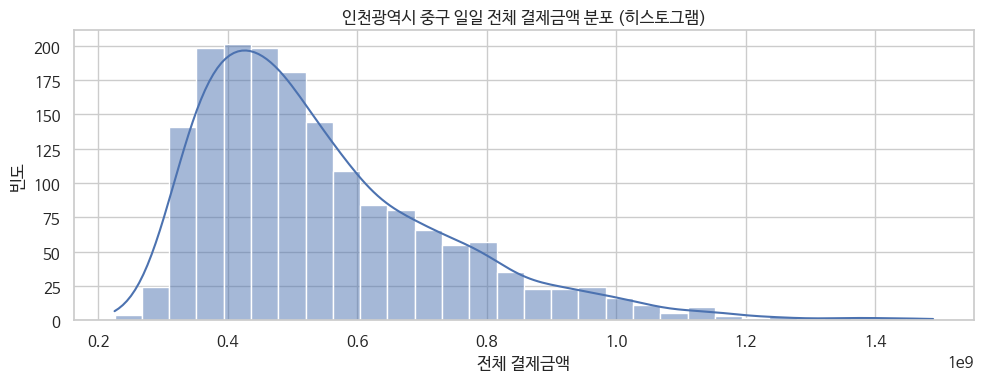

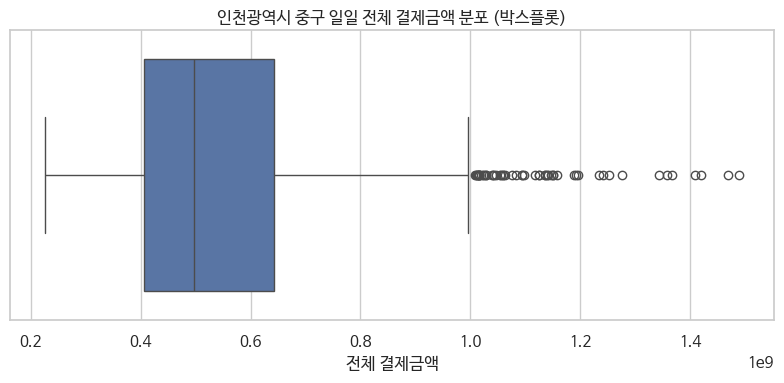

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1️⃣ Seaborn 테마 먼저 적용
sns.set_theme(style='whitegrid')

# 2️⃣ 폰트 직접 명시적으로 설정 (반드시 sns 설정 이후)
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=fontpath)
plt.rc('font', family=fontprop.get_name())
plt.rcParams['axes.unicode_minus'] = False

# 폰트 설정 확인
print('현재 설정된 폰트:', fontprop.get_name())

# 3️⃣ 데이터 로드 및 처리
df = pd.read_csv('/content/전처리된_인천e음카드_데이터.csv', encoding='utf-8-sig')
df['일자'] = pd.to_datetime(df['일자'])

# 결측치 개수 확인

print("결측치 개수")
missing_values = df.isnull().sum()
print(missing_values)

# 데이터 집계
df_grouped = df.groupby(['지역', '일자'])['전체금액'].sum().reset_index()

# 지역별 분포 시각화 (반복)
regions = df_grouped['지역'].unique()

for region in regions:
    df_region = df_grouped[df_grouped['지역'] == region]

    # 히스토그램
    plt.figure(figsize=(10, 4))
    sns.histplot(df_region['전체금액'], bins=30, kde=True)
    plt.title(f'{region} 일일 전체 결제금액 분포 (히스토그램)')
    plt.xlabel('전체 결제금액')
    plt.ylabel('빈도')
    plt.tight_layout()
    plt.show()

    # 박스플롯
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_region['전체금액'])
    plt.title(f'{region} 일일 전체 결제금액 분포 (박스플롯)')
    plt.xlabel('전체 결제금액')
    plt.tight_layout()
    plt.show()


월별 캐시백 비율 병합

In [ ]:
import pandas as pd

# 데이터프레임 생성
data = []
regions = ["인천광역시 서구", "인천광역시 계양구", "인천광역시 남동구", "인천광역시 동구", "인천광역시 중구", "인천광역시 미추홀구", "인천광역시 부평구", "인천광역시 연수구", "인천광역시 옹진군", "인천광역시 강화군"]
dates = pd.date_range(start="2020-07-01", end="2025-02-01", freq="MS")

for date in dates:
    for region in regions:
        if date <= pd.Timestamp("2022-06-01"):
            data.append([date.strftime('%Y-%m-%d'), region, "10%", "10%", "10%", "100만원"])
        elif pd.Timestamp("2022-07-01") <= date <= pd.Timestamp("2022-09-01"):
            data.append([date.strftime('%Y-%m-%d'), region, "5%", "5%", "5%", "30만원"])
        elif pd.Timestamp("2022-10-01") <= date <= pd.Timestamp("2023-04-01"):
            if region in ["인천광역시 강화군", "인천광역시 옹진군"]:
                data.append([date.strftime('%Y-%m-%d'), region, "10%", "10%", "5%", "30만원"])
            else:
                data.append([date.strftime('%Y-%m-%d'), region, "10%", "5%", "5%", "30만원"])
        elif date in [pd.Timestamp("2023-05-01"), pd.Timestamp("2023-09-01"), pd.Timestamp("2024-05-01"), pd.Timestamp("2024-09-01")]:
            if region in ["인천광역시 강화군", "인천광역시 옹진군"]:
                data.append([date.strftime('%Y-%m-%d'), region, "10%", "10%", "7%", "100만원"])
            else:
                data.append([date.strftime('%Y-%m-%d'), region, "10%", "7%", "7%", "100만원"])
        elif pd.Timestamp("2023-09-25") <= date:
            if region in ["인천광역시 강화군", "인천광역시 옹진군"]:
                data.append([date.strftime('%Y-%m-%d'), region, "10%", "10%", "0%", "30만원"])
            else:
                data.append([date.strftime('%Y-%m-%d'), region, "10%", "5%", "0%", "30만원"])
        else:
            data.append([date.strftime('%Y-%m-%d'), region, "10%", "5%", "5%", "30만원"])

# DataFrame으로 저장
df = pd.DataFrame(data, columns=['일자', '지역', '연매출 3억원 이하', '연매출 3억~30억원', '연매출 30억원 초과', '월 결제 한도'])

# CSV 파일 저장
df.to_csv('인천e음카드_캐시백정책_2020_2025.csv', encoding='utf-8-sig', index=False)

print("파일 저장 완료: '인천e음카드_캐시백정책_2020_2025.csv'")

파일 저장 완료: '인천e음카드_캐시백정책_2020_2025.csv'


In [ ]:
print(df)

             일자          지역 연매출 3억원 이하 연매출 3억~30억원 연매출 30억원 초과 월 결제 한도
0    2020-07-01    인천광역시 서구        10%         10%         10%   100만원
1    2020-07-01   인천광역시 계양구        10%         10%         10%   100만원
2    2020-07-01   인천광역시 남동구        10%         10%         10%   100만원
3    2020-07-01    인천광역시 동구        10%         10%         10%   100만원
4    2020-07-01    인천광역시 중구        10%         10%         10%   100만원
..          ...         ...        ...         ...         ...     ...
555  2025-02-01  인천광역시 미추홀구        10%          5%          0%    30만원
556  2025-02-01   인천광역시 부평구        10%          5%          0%    30만원
557  2025-02-01   인천광역시 연수구        10%          5%          0%    30만원
558  2025-02-01   인천광역시 옹진군        10%         10%          0%    30만원
559  2025-02-01   인천광역시 강화군        10%         10%          0%    30만원

[560 rows x 6 columns]


결제금액 이상치 제거 / 시계열 테스트

In [ ]:
# ✅ 필요한 라이브러리 설치 (Colab 첫 실행 시 1회)
!pip install tensorflow --quiet

In [ ]:
# 나눔폰트 설치
!apt-get -qq install -y fonts-nanum

# 📌 2단계: 캐시 리셋
!rm -rf ~/.cache/matplotlib

#런타임 다시 시작

Selecting previously unselected package fonts-nanum.
(Reading database ... 126213 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Seaborn 설정
sns.set_theme(style='whitegrid')

# 📌 나눔고딕 적용
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 확인
print('폰트 적용 완료:', plt.rcParams['font.family'])

폰트 적용 완료: ['NanumGothic']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


<ipython-input-19-f7e3805299d6>:102: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


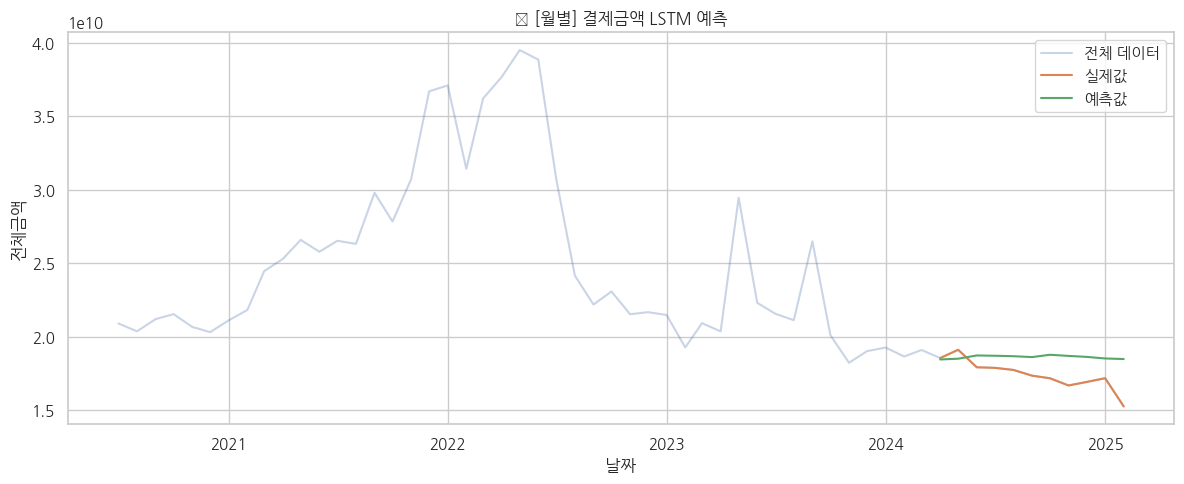

✅ MAE: 1310612898.18, RMSE: 1534617302.23


KeyError: '일자'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# ✅ 2. 파일 불러오기
df = pd.read_csv("/content/전처리된_인천e음카드_데이터.csv")
df_cashback = pd.read_csv("/content/인천e음카드_월별_캐시백비율.csv")
df_pop = pd.read_csv("/content/인천광역시_행정동병_연령별_성별_인구수.csv")

# ✅ 컬럼 공백 제거
df.columns = df.columns.str.strip()
df_cashback.columns = df_cashback.columns.str.strip()
df_pop.columns = df_pop.columns.str.strip()

# ✅ 날짜 처리
df['일자'] = pd.to_datetime(df['일자'])
df['월'] = df['일자'].dt.to_period('M').astype(str)
df_cashback['월'] = pd.to_datetime(df_cashback['일자']).dt.to_period('M').astype(str)
df_pop['일자'] = pd.to_datetime(df_pop['일자'])
df_pop['월'] = df_pop['일자'].dt.to_period('M').astype(str)

# ✅ 인구수 집계
df_pop['총인구수'] = df_pop['여/총인구수'] + df_pop['남/총인구수']
df_pop_grouped = df_pop.groupby(['월', '지역'])['총인구수'].sum().reset_index()

# ✅ 캐시백 수치 변환
def clean_cashback(c):
    return pd.to_numeric(c.str.replace('%','').str.replace(',',''), errors='coerce') / 100
def clean_limit(c):
    return pd.to_numeric(c.str.replace('만원','').str.replace(',',''), errors='coerce') * 10000

df_cashback['연매출 3억원 이하'] = clean_cashback(df_cashback['연매출 3억원 이하'])
df_cashback['연매출 3억~30억원'] = clean_cashback(df_cashback['연매출 3억~30억원'])
df_cashback['연매출 30억원 초과'] = clean_cashback(df_cashback['연매출 30억원 초과'])
df_cashback['월 결제 한도'] = clean_limit(df_cashback['월 결제 한도'])

# ✅ 일별 결제금액 집계 및 병합
df_daily = df.groupby(['일자', '지역'])['전체금액'].sum().reset_index()
df_daily['월'] = df_daily['일자'].dt.to_period('M').astype(str)
df_merged = df_daily.merge(df_cashback, on=['월', '지역'], how='left')
df_merged = df_merged.merge(df_pop_grouped, on=['월', '지역'], how='left')

# ✅ 시계열 입력 생성 함수
def create_sequences(X, y, lookback=30):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i + lookback])
    return np.array(Xs), np.array(ys)

# ✅ LSTM 예측 함수
def lstm_forecast(df, time_col='일자', value_col='전체금액', exog_cols=[], lookback=30, title='LSTM 예측'):
    df = df.sort_values(time_col).copy()
    df = df.dropna(subset=exog_cols + [value_col])

    X = df[exog_cols].values
    y = df[value_col].values.reshape(-1, 1)

    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_x.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)
    X_seq = X_seq.reshape((X_seq.shape[0], lookback, len(exog_cols)))

    split = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    model = Sequential([
        Input(shape=(lookback, len(exog_cols))),
        LSTM(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)

    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    test_dates = df[time_col].iloc[lookback + split:lookback + split + len(y_pred)]

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[value_col], label='전체 데이터', alpha=0.3)
    plt.plot(test_dates, y_true, label='실제값')
    plt.plot(test_dates, y_pred, label='예측값')
    plt.title(title)
    plt.xlabel('날짜')
    plt.ylabel(value_col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"✅ MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# ✅ 월별 예측
region = '인천광역시 계양구'
df_month = df_merged.copy()
df_month_grouped = df_month.groupby(['월', '지역']).agg({
    '전체금액': 'sum',
    '총인구수': 'mean',
    '연매출 3억원 이하': 'mean',
    '연매출 3억~30억원': 'mean',
    '연매출 30억원 초과': 'mean',
    '월 결제 한도': 'mean'
}).reset_index()
df_month_region = df_month_grouped[df_month_grouped['지역'] == region].copy()
df_month_region['월'] = pd.to_datetime(df_month_region['월'], format='%Y-%m')

lstm_forecast(
    df_month_region,
    time_col='월',
    value_col='전체금액',
    exog_cols=['총인구수', '연매출 3억원 이하', '연매출 3억~30억원', '연매출 30억원 초과', '월 결제 한도'],
    lookback=3,
    title='📅 [월별] 결제금액 LSTM 예측'
)
df.columns = df.columns.str.strip()
# ✅ 일별 예측
df_day_region = df_merged[df_merged['지역'] == region].copy()
df_day_region['일자'] = pd.to_datetime(df_day_region['일자'])

lstm_forecast(
    df_day_region,
    time_col='일자',
    value_col='전체금액',
    exog_cols=['총인구수', '연매출 3억원 이하', '연매출 3억~30억원', '연매출 30억원 초과', '월 결제 한도'],
    lookback=30,
    title='📆 [일별] 결제금액 LSTM 예측'
)
